# Group barcodes to make pseudo-barcodes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def distribute_values_3element_greedy(sums):
    if len(sums) != 15:
        raise ValueError("This function requires exactly 15 elements.")

    # Sort the sums while keeping track of original indices
    sorted_indices = sorted(range(len(sums)), key=lambda i: sums[i], reverse=True)
    group_assignments = [None] * len(sums)
    group_sums = [0] * 5
    group_counters = [0] * 5

    for idx in sorted_indices:
        # Filter groups that have fewer than 3 members
        eligible_groups = [(sum_, group_idx) for group_idx, sum_ in enumerate(group_sums) if group_counters[group_idx] < 3]
        
        # Sort eligible groups by their current sum to find the one with the minimal sum
        eligible_groups.sort(key=lambda x: x[0])
        
        # Check if there are any eligible groups left
        if not eligible_groups:
            raise ValueError("No eligible groups found. This should not happen with 15 elements and 5 groups.")

        min_sum_group_index = eligible_groups[0][1]
        group_assignments[idx] = min_sum_group_index + 1  # Assign to groups 1-5
        group_counters[min_sum_group_index] += 1
        group_sums[min_sum_group_index] += sums[idx]

    return group_assignments

def distribute_values_greedy(sums):
    # Sort the sums while keeping track of original indices
    sorted_indices = sorted(range(len(sums)), key=lambda i: sums[i], reverse=True)
    group_assignments = [0] * len(sums)
    group_sums = [0] * 5

    for idx in sorted_indices:
        min_group_index = group_sums.index(min(group_sums))
        group_assignments[idx] = min_group_index + 1  # Assign to groups 1-5
        group_sums[min_group_index] += sums[idx]

    return group_assignments

def apply_greedy_to_df(df, grouping_func):
    num_rows = len(df)
    group_assignments = []

    for start_idx in range(0, num_rows, 15):
        end_idx = start_idx + 15
        enhancer_sums = df.iloc[start_idx:end_idx].sum(axis=1).tolist()
        groups = grouping_func(enhancer_sums)
        group_assignments.extend(groups)
    
    return group_assignments

def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('D1-', '-').replace('D2-', '-')


def count_group_assignments(df):
    # Number of rows in the DataFrame
    num_rows = len(df)
    
    # Initialize a dictionary to hold the counts for each 15-row chunk
    group_counts_per_chunk = {}

    # Iterate over the DataFrame in chunks of 15 rows
    for start_idx in range(0, num_rows, 15):
        end_idx = start_idx + 15
        chunk = df.iloc[start_idx:end_idx]
        
        # Count the occurrences of each group in this chunk
        counts = chunk['Group'].value_counts().to_dict()
        
        # Store the counts in the dictionary with the chunk's start index as the key
        group_counts_per_chunk[start_idx] = counts

    return group_counts_per_chunk

def sum_barcode_groups(df):
    # Create the "Pseudo-barcode" column
    df['Pseudo-barcode'] = df['enhancer_id'].astype(str) + "_Group_" + df['Group'].astype(str)
    
    # Group by "Pseudo-barcode" and sum numeric columns
    aggregated_df = df.groupby('Pseudo-barcode', as_index=False).sum(numeric_only=True)
    
    # If you need to split the "Pseudo-barcode" back into "enhancer_id" and "Group" or retain these in the aggregated output,
    # it's more efficient to keep them during the aggregation rather than splitting afterwards.
    # However, for simplicity and direct summing, this step is not shown here.
    
    # The result is the aggregated DataFrame with each "Pseudo-barcode" having summed numeric values
    return aggregated_df



df_index= pd.read_csv("indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv",index_col=0)["enhancer_id"]

import pandas as pd

def distribute_values_order(df):
    # Assuming 'enhancer_id' is not part of the columns to sum.
    cols_to_sum = [col for col in df.columns if col != 'enhancer_id']
    
    # Calculate the sum across the specified columns for each row.
    df['sum'] = df[cols_to_sum].sum(axis=1)
    
    # Sort the DataFrame based on the 'enhancer_id' and the sum, to keep groups together and in order.
    df = df.sort_values(by=['enhancer_id', 'sum'], ascending=[True, False])
    
    # Function to assign groups within each enhancer_id block.
    def assign_group(x):
        # Calculate ranks within the current block of rows.
        x['Group'] = pd.qcut(x['sum'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
        return x
    
    # Apply the group assignment function to each block of 15 rows.
    df = df.groupby('enhancer_id', group_keys=False).apply(assign_group)
    
    # Drop the temporary 'sum' column used for sorting and ranking.
    df = df.drop(columns=['sum'])
    
    return df


In [3]:
df_THP1 = pd.read_csv("read_counts_R1R2/THP1_DNA_RNA.csv", index_col=0).iloc[986:, :]

df_THP1_DNA = df_THP1[
    [
        "ZC83D-MPRA3-THP1mac-26-Naive",
        "ZC86D-MPRA3-THP1mac-26-Naive",
        "ZC91D-MPRA3-THP1mac-26-Naive",
        "ZC61D-MPRA3-THP1mac-26-Naive",
        "ZC125D-MPRA3-THP1mac-26-LPSIFNG",
        "ZC114D-MPRA3-THP1mac-26-LPSIFNG",
        "ZC115D-MPRA3-THP1mac-26-LPSIFNG",
    ]
]

DNA_columns = [
    "ZC102D1-MPRA3-AP1134misc-26",
    "ZC102D2-MPRA3-AP1134misc-26",
    "ZC98D1-MPRA3-AP1133misc-26",
    "ZC98D2-MPRA3-AP1133misc-26",
    "ZC106D1-MPRA3-AP1120misc-26",
    "ZC106D2-MPRA3-AP1120misc-26",
    "ZC110D1-MPRA3-AP1121misc-26",
    "ZC110D2-MPRA3-AP1121misc-26",
]

grouped_df = (
    pd.read_csv("read_counts_R1R2/Brain_DNA.csv", index_col=0)
    .iloc[986:, :][DNA_columns]
    .groupby(process_column_name, axis=1)
    .sum()
)

grouped_df = pd.merge(grouped_df, df_index, left_index=True, right_index=True)

# Apply the function
grouped_df = distribute_values_order(grouped_df)
grouped_df = pd.merge(grouped_df, df_THP1_DNA, left_index=True, right_index=True)

pseudo_barcodes_df = sum_barcode_groups(grouped_df).set_index("Pseudo-barcode").sort_index()

sum_brain = pd.DataFrame(pseudo_barcodes_df.iloc[:, 0:4].sum(axis=1))
sum_brain.columns = ["Sum_brain"]

enhancer_id = (
    grouped_df[["enhancer_id", "Pseudo-barcode"]]
    .drop_duplicates("Pseudo-barcode")
    .set_index("Pseudo-barcode")
)

pseudo_barcodes_df = pd.merge(pseudo_barcodes_df, sum_brain, left_index=True, right_index=True)
pseudo_barcodes_df = pd.merge(pseudo_barcodes_df, enhancer_id, left_index=True, right_index=True)

C:\Users\da111\AppData\Local\Temp\ipykernel_39880\3129934659.py:29: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(process_column_name, axis=1)
C:\Users\da111\AppData\Local\Temp\ipykernel_39880\567609251.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('enhancer_id', group_keys=False).apply(assign_group)


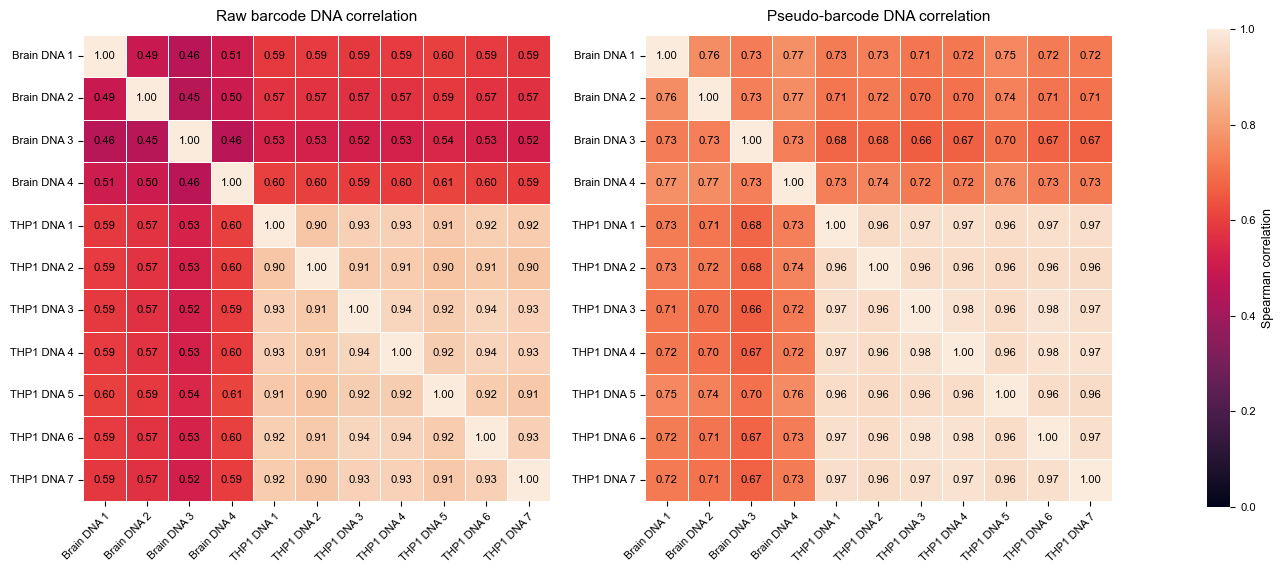

In [4]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# --------------------------------------------------
# Make text editable in Illustrator
# --------------------------------------------------
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "Arial"

# --------------------------------------------------
# Optional: cleaner sample names for publication
# --------------------------------------------------
rename_dict = {
    "ZC102-MPRA3-AP1134misc-26": "Brain DNA 1",
    "ZC98-MPRA3-AP1133misc-26": "Brain DNA 2",
    "ZC106-MPRA3-AP1120misc-26": "Brain DNA 3",
    "ZC110-MPRA3-AP1121misc-26": "Brain DNA 4",
    "ZC83D-MPRA3-THP1mac-26-Naive": "THP1 DNA 1",
    "ZC86D-MPRA3-THP1mac-26-Naive": "THP1 DNA 2",
    "ZC91D-MPRA3-THP1mac-26-Naive": "THP1 DNA 3",
    "ZC61D-MPRA3-THP1mac-26-Naive": "THP1 DNA 4",
    "ZC125D-MPRA3-THP1mac-26-LPSIFNG": "THP1 DNA 5",
    "ZC114D-MPRA3-THP1mac-26-LPSIFNG": "THP1 DNA 6",
    "ZC115D-MPRA3-THP1mac-26-LPSIFNG": "THP1 DNA 7",
}

display_order = [
    "Brain DNA 1",
    "Brain DNA 2",
    "Brain DNA 3",
    "Brain DNA 4",
    "THP1 DNA 1",
    "THP1 DNA 2",
    "THP1 DNA 3",
    "THP1 DNA 4",
    "THP1 DNA 5",
    "THP1 DNA 6",
    "THP1 DNA 7",
]

# --------------------------------------------------
# Build pseudo-barcode correlation matrix
# --------------------------------------------------
plot_df_pseudo = pseudo_barcodes_df.drop(columns=["enhancer_id"], errors="ignore").copy()
corr_pseudo = plot_df_pseudo.corr(method="spearman")
corr_pseudo = corr_pseudo.rename(index=rename_dict, columns=rename_dict)

# --------------------------------------------------
# Build raw barcode correlation matrix
# --------------------------------------------------
plot_df_raw = grouped_df.drop(
    columns=["enhancer_id", "Group", "Pseudo-barcode"],
    errors="ignore"
).copy()
corr_raw = plot_df_raw.corr(method="spearman")
corr_raw = corr_raw.rename(index=rename_dict, columns=rename_dict)

shared = [x for x in display_order if x in corr_raw.index and x in corr_pseudo.index]
corr_raw_ord = corr_raw.loc[shared, shared]
corr_pseudo_ord = corr_pseudo.loc[shared, shared]

# --------------------------------------------------
# Layout: two equal heatmaps + one separate colorbar axis
# --------------------------------------------------
fig = plt.figure(figsize=(14.8, 6.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# left: raw barcode
hm1 = sns.heatmap(
    corr_raw_ord,
    ax=ax1,
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize":8, "color":"black"},
    cbar=False
)
ax1.set_title("Raw barcode DNA correlation", fontsize=11, pad=10)
ax1.set_xticklabels(
    ax1.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=8
)
ax1.set_yticklabels(
    ax1.get_yticklabels(),
    rotation=0,
    fontsize=8
)

# right: pseudo-barcode
hm2 = sns.heatmap(
    corr_pseudo_ord,
    ax=ax2,
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize":8, "color":"black"},
    cbar=True,
    cbar_ax=cax
)
ax2.set_title("Pseudo-barcode DNA correlation", fontsize=11, pad=10)
ax2.set_xticklabels(
    ax2.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=8
)
ax2.set_yticklabels(
    ax2.get_yticklabels(),
    rotation=0,
    fontsize=8
)

# clean spines
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(False)

# colorbar formatting
cax.tick_params(labelsize=8)
cax.set_ylabel("Spearman correlation", fontsize=9)

plt.savefig("raw_vs_pseudo_barcode_correlation_equal_size.pdf", dpi=300, bbox_inches="tight")
plt.show()

Wrote: read_counts_R1R2\Brain_RNA_15barcodes.csv


C:\Users\da111\AppData\Local\Temp\ipykernel_39880\1839896360.py:44: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_brain = pd.read_csv("read_counts_R1R2/Brain_RNA_15barcodes.csv", index_col=0)
C:\Users\da111\AppData\Local\Temp\ipykernel_39880\1839896360.py:76: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grouped_df = df_brain[RNA_columns].groupby(process_column_name, axis=1).sum()
C:\Users\da111\AppData\Local\Temp\ipykernel_39880\567609251.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('enhancer_id', group_keys=False).apply(assign_group)


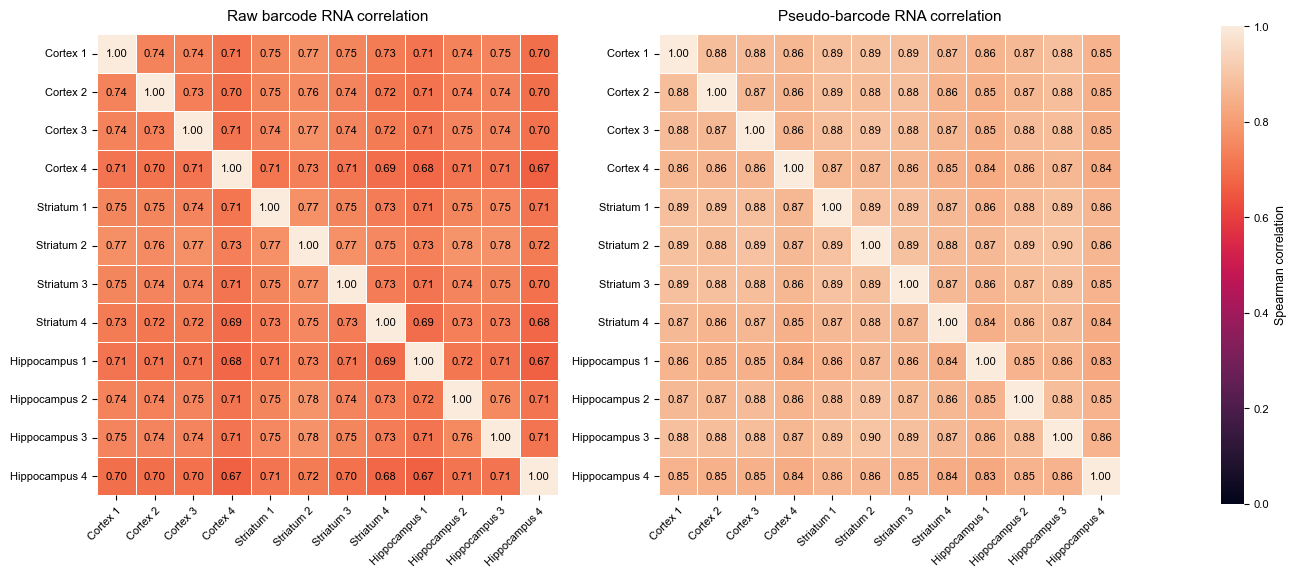

In [7]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

in_path = Path("read_counts_R1R2/Brain_RNA.csv")
out_path = Path("read_counts_R1R2/Brain_RNA_15barcodes.csv")

df = pd.read_csv(in_path)

# Rule: first 986 rows are controls
n_control_rows = 986
df["__row_order__"] = range(len(df))

controls = df.iloc[:n_control_rows].copy()
non_controls = df.iloc[n_control_rows:].copy()

# Define enhancer identity by stripping last ".<barcode>" from ID
def base_enhancer_id(id_str: str) -> str:
    s = str(id_str)
    if "." in s:
        return s.rsplit(".", 1)[0]
    return s

controls["__enhancer_base__"] = controls["ID"].map(base_enhancer_id)

# Keep first 15 barcodes per control enhancer, preserving file order
controls = controls.sort_values("__row_order__", kind="mergesort")
controls["__within_enh__"] = controls.groupby("__enhancer_base__", sort=False).cumcount()
controls_15 = controls.loc[controls["__within_enh__"] < 15].copy()

# Recombine and write
out_df = pd.concat([controls_15, non_controls], axis=0).sort_values("__row_order__", kind="mergesort")
out_df = out_df.drop(columns=["__row_order__"], errors="ignore")
out_df.to_csv(out_path, index=False)

print("Wrote:", out_path)

# =========================================================
# Brain RNA pseudobarcodes
# =========================================================
df_brain = pd.read_csv("read_counts_R1R2/Brain_RNA_15barcodes.csv", index_col=0)

RNA_columns = [
    "ZC99R-MPRA3-AP1134-26-Cortex",
    "ZC99R2-MPRA3-AP1134-26-Cortex",
    "ZC100R-MPRA3-AP1134-26-Striatum",
    "ZC100R2-MPRA3-AP1134-26-Striatum",
    "ZC101R-MPRA3-AP1134-26-Hippocampus",
    "ZC101R2-MPRA3-AP1134-26-Hippocampus",
    "ZC95R-MPRA3-AP1133-26-Cortex",
    "ZC95R2-MPRA3-AP1133-26-Cortex",
    "ZC96R-MPRA3-AP1133-26-Striatum",
    "ZC96R2-MPRA3-AP1133-26-Striatum",
    "ZC97R-MPRA3-AP1133-26-Hippocampus",
    "ZC97R2-MPRA3-AP1133-26-Hippocampus",
    "ZC103R-MPRA3-AP1120-26-Cortex",
    "ZC103R2-MPRA3-AP1120-26-Cortex",
    "ZC104R-MPRA3-AP1120-26-Striatum",
    "ZC104R2-MPRA3-AP1120-26-Striatum",
    "ZC105R-MPRA3-AP1120-26-Hippocampus",
    "ZC105R2-MPRA3-AP1120-26-Hippocampus",
    "ZC107R-MPRA3-AP1121-26-Cortex",
    "ZC107R2-MPRA3-AP1121-26-Cortex",
    "ZC108R-MPRA3-AP1121-26-Striatum",
    "ZC108R2-MPRA3-AP1121-26-Striatum",
    "ZC109R-MPRA3-AP1121-26-Hippocampus",
    "ZC109R2-MPRA3-AP1121-26-Hippocampus",
]

def process_column_name(name):
    return name.replace("R-", "-").replace("R2-", "-")

grouped_df = df_brain[RNA_columns].groupby(process_column_name, axis=1).sum()
grouped_df = pd.merge(grouped_df, df_index, left_index=True, right_index=True)
grouped_df = distribute_values_order(grouped_df)

pseudo_barcodes_df = sum_barcode_groups(grouped_df).set_index("Pseudo-barcode").sort_index()

enhancer_id = (
    grouped_df[["enhancer_id", "Pseudo-barcode"]]
    .drop_duplicates("Pseudo-barcode")
    .set_index("Pseudo-barcode")
)

pseudo_barcodes_df = pd.merge(
    pseudo_barcodes_df,
    enhancer_id,
    left_index=True,
    right_index=True
)

# --------------------------------------------------
# Make text editable in Illustrator
# --------------------------------------------------
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "Arial"

# --------------------------------------------------
# Cleaner sample names
# --------------------------------------------------
rename_dict = {
    "ZC95-MPRA3-AP1133-26-Cortex": "Cortex 1",
    "ZC96-MPRA3-AP1133-26-Striatum": "Striatum 1",
    "ZC97-MPRA3-AP1133-26-Hippocampus": "Hippocampus 1",
    "ZC99-MPRA3-AP1134-26-Cortex": "Cortex 2",
    "ZC100-MPRA3-AP1134-26-Striatum": "Striatum 2",
    "ZC101-MPRA3-AP1134-26-Hippocampus": "Hippocampus 2",
    "ZC103-MPRA3-AP1120-26-Cortex": "Cortex 3",
    "ZC104-MPRA3-AP1120-26-Striatum": "Striatum 3",
    "ZC105-MPRA3-AP1120-26-Hippocampus": "Hippocampus 3",
    "ZC107-MPRA3-AP1121-26-Cortex": "Cortex 4",
    "ZC108-MPRA3-AP1121-26-Striatum": "Striatum 4",
    "ZC109-MPRA3-AP1121-26-Hippocampus": "Hippocampus 4",
}

display_order = [
    "Cortex 1", "Cortex 2", "Cortex 3", "Cortex 4",
    "Striatum 1", "Striatum 2", "Striatum 3", "Striatum 4",
    "Hippocampus 1", "Hippocampus 2", "Hippocampus 3", "Hippocampus 4",
]

# --------------------------------------------------
# Raw barcode RNA correlation
# --------------------------------------------------
plot_df_raw = grouped_df.drop(
    columns=["enhancer_id", "Group", "Pseudo-barcode"],
    errors="ignore"
).copy()

corr_raw = plot_df_raw.corr(method="spearman")
corr_raw = corr_raw.rename(index=rename_dict, columns=rename_dict)

# --------------------------------------------------
# Pseudo-barcode RNA correlation
# --------------------------------------------------
plot_df_pseudo = pseudo_barcodes_df.drop(columns=["enhancer_id"], errors="ignore").copy()
corr_pseudo = plot_df_pseudo.corr(method="spearman")
corr_pseudo = corr_pseudo.rename(index=rename_dict, columns=rename_dict)

# --------------------------------------------------
# Fixed display order
# --------------------------------------------------
shared = [x for x in display_order if x in corr_raw.index and x in corr_pseudo.index]

corr_raw_ord = corr_raw.loc[shared, shared]
corr_pseudo_ord = corr_pseudo.loc[shared, shared]

# --------------------------------------------------
# Plot: equal-sized heatmaps + separate colorbar axis
# --------------------------------------------------
fig = plt.figure(figsize=(14.8, 6.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# left: raw barcode
hm1 = sns.heatmap(
    corr_raw_ord,
    ax=ax1,
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize":8, "color":"black"},
    cbar=False
)

ax1.set_title("Raw barcode RNA correlation", fontsize=11, pad=10)
ax1.set_xticklabels(
    ax1.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=8
)
ax1.set_yticklabels(
    ax1.get_yticklabels(),
    rotation=0,
    fontsize=8
)

# right: pseudo-barcode
hm2 = sns.heatmap(
    corr_pseudo_ord,
    ax=ax2,
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize":8, "color":"black"},
    cbar=True,
    cbar_ax=cax
)

ax2.set_title("Pseudo-barcode RNA correlation", fontsize=11, pad=10)
ax2.set_xticklabels(
    ax2.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=8
)
ax2.set_yticklabels(
    ax2.get_yticklabels(),
    rotation=0,
    fontsize=8
)

# clean spines
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(False)

# colorbar formatting
cax.tick_params(labelsize=8)
cax.set_ylabel("Spearman correlation", fontsize=9)

plt.savefig("raw_vs_pseudo_barcode_RNA_correlation_NG_style.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
pseudo_barcodes_df[['ZC102-MPRA3-AP1134misc-26', 'ZC106-MPRA3-AP1120misc-26',
       'ZC110-MPRA3-AP1121misc-26', 'ZC98-MPRA3-AP1133misc-26']].to_csv("read_counts_R1R2/BrainR1R2merged20240404_DNA_pseudo_barcodes.csv")
RNA_columns = pd.read_csv('read_counts_R1R2/BrainR1R2merged20240404_RNA_matched_barcodes.csv',index_col=0).columns
df_tmp = pd.DataFrame()
for i in RNA_columns[:-1]:
    df_tmp[i] = pseudo_barcodes_df["Sum_brain"]
df_tmp["enhancer_id"]=pseudo_barcodes_df["enhancer_id"]
df_tmp.to_csv("read_counts_R1R2/BrainR1R2merged20240404BrainSum_DNA_matched_barcodes.csv")

Rows 2505 to 2519: {3: 13, 1: 1, 2: 1}
Rows 2520 to 2534: {3: 13, 1: 1, 2: 1}
Rows 2535 to 2549: {3: 13, 1: 1, 2: 1}
Rows 2550 to 2564: {3: 13, 1: 1, 2: 1}
Rows 2565 to 2579: {3: 13, 1: 1, 2: 1}
Rows 2580 to 2594: {4: 12, 1: 1, 2: 1, 3: 1}
Rows 2595 to 2609: {3: 13, 1: 1, 2: 1}
Rows 2610 to 2624: {3: 13, 1: 1, 2: 1}
Rows 15015 to 15029: {3: 13, 1: 1, 2: 1}
Rows 15030 to 15044: {2: 14, 1: 1}


/tmp/ipykernel_53826/2334740360.py:45: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.clustermap(pseudo_barcodes_df.drop("Group",axis=1).corr('spearman'),vmin=0,annot=True)


Text(0.5, 1.0, 'Group barcodes to reduce variation')

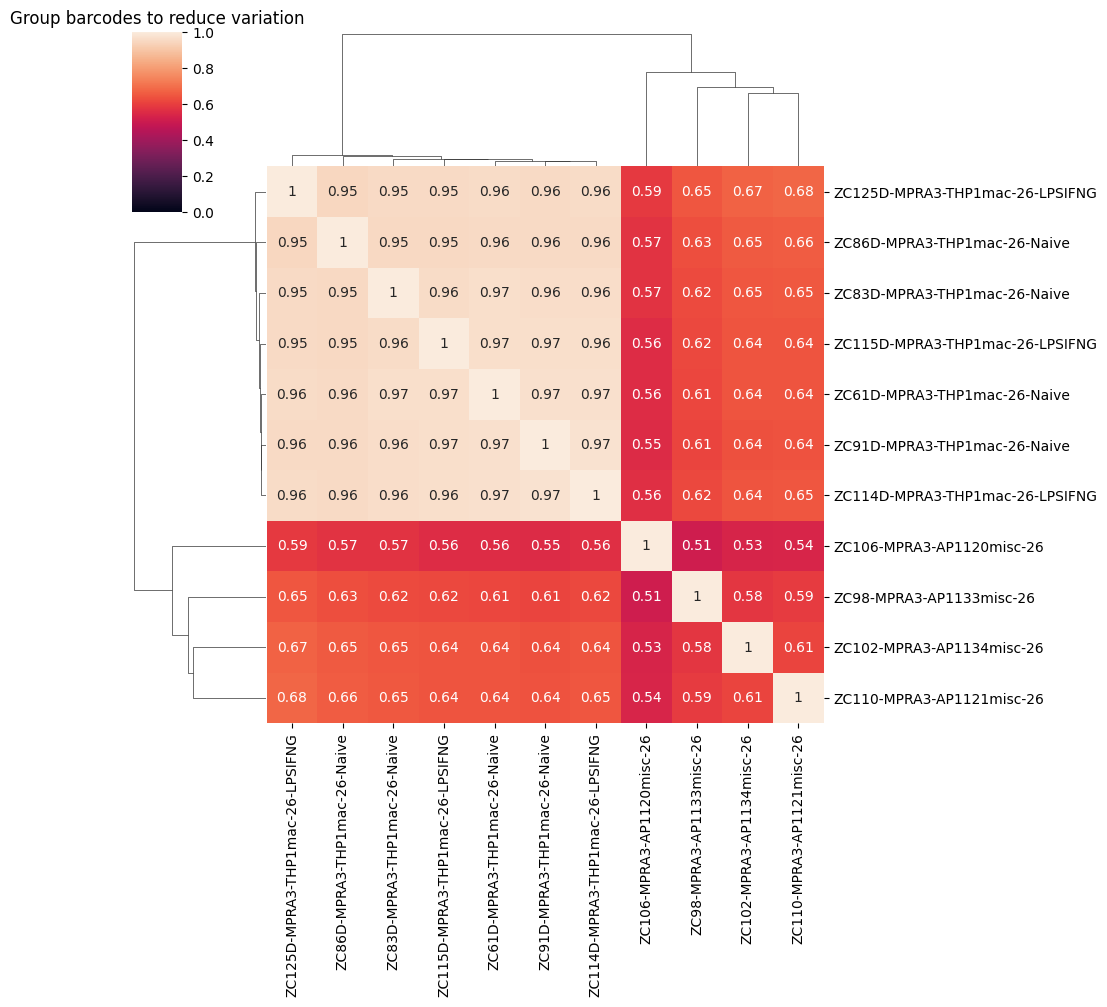

In [32]:
df_THP1 = pd.read_csv("read_counts_R1R2/THP1_DNA_RNA.csv",index_col=0).iloc[986:,:]
df_THP1_DNA = df_THP1 [['ZC83D-MPRA3-THP1mac-26-Naive',
        'ZC86D-MPRA3-THP1mac-26-Naive',
       'ZC91D-MPRA3-THP1mac-26-Naive', 
        'ZC61D-MPRA3-THP1mac-26-Naive',
       'ZC125D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC114D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC115D-MPRA3-THP1mac-26-LPSIFNG']]

DNA_columns = ['ZC102D1-MPRA3-AP1134misc-26', 'ZC102D2-MPRA3-AP1134misc-26',
               'ZC98D1-MPRA3-AP1133misc-26', 'ZC98D2-MPRA3-AP1133misc-26',
       'ZC106D1-MPRA3-AP1120misc-26', 'ZC106D2-MPRA3-AP1120misc-26',
       'ZC110D1-MPRA3-AP1121misc-26', 'ZC110D2-MPRA3-AP1121misc-26',
       ]

grouped_df= pd.read_csv("read_counts_R1R2/Brain_DNA.csv",index_col=0).iloc[986:,:][DNA_columns].groupby(process_column_name, axis=1).sum()

# Apply the function
group_assignments = apply_greedy_to_df(grouped_df, distribute_values_greedy)
grouped_df['Group'] = group_assignments
grouped_df = pd.concat([grouped_df,df_THP1_DNA],axis=1)
# Example usage
index_ranges_to_drop = []
group_counts = count_group_assignments(grouped_df)
for start_idx, counts in group_counts.items():
    if len(counts)<5:
        print(f"Rows {start_idx} to {start_idx+14}: {counts}")
        index_ranges_to_drop.append([start_idx, start_idx+14])
# Create a boolean array where all elements are initially set to True
keep_mask = np.ones(len(grouped_df), dtype=bool)
# Mark rows within the specified ranges as False (to drop)
for start, end in index_ranges_to_drop:
    keep_mask[start:end+1] = False
# Use the mask to filter the DataFrame
grouped_df_filtered = grouped_df[keep_mask]

# Sum up barcode groups and assign pseudo-barcodes
pseudo_barcodes_df = sum_barcode_groups(grouped_df_filtered )
pseudo_barcodes_df['Group'] = pseudo_barcodes_df['Group']/3
pseudo_barcodes_df

import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(pseudo_barcodes_df.drop("Group",axis=1).corr('spearman'),vmin=0,annot=True)
plt.title("Group barcodes to reduce variation")

/tmp/ipykernel_53826/1085514928.py:44: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.clustermap(pseudo_barcodes_df.drop("Group",axis=1).corr('spearman'),vmin=0,annot=True)


Text(0.5, 1.0, 'Group barcodes to reduce variation, limit 3 elements')

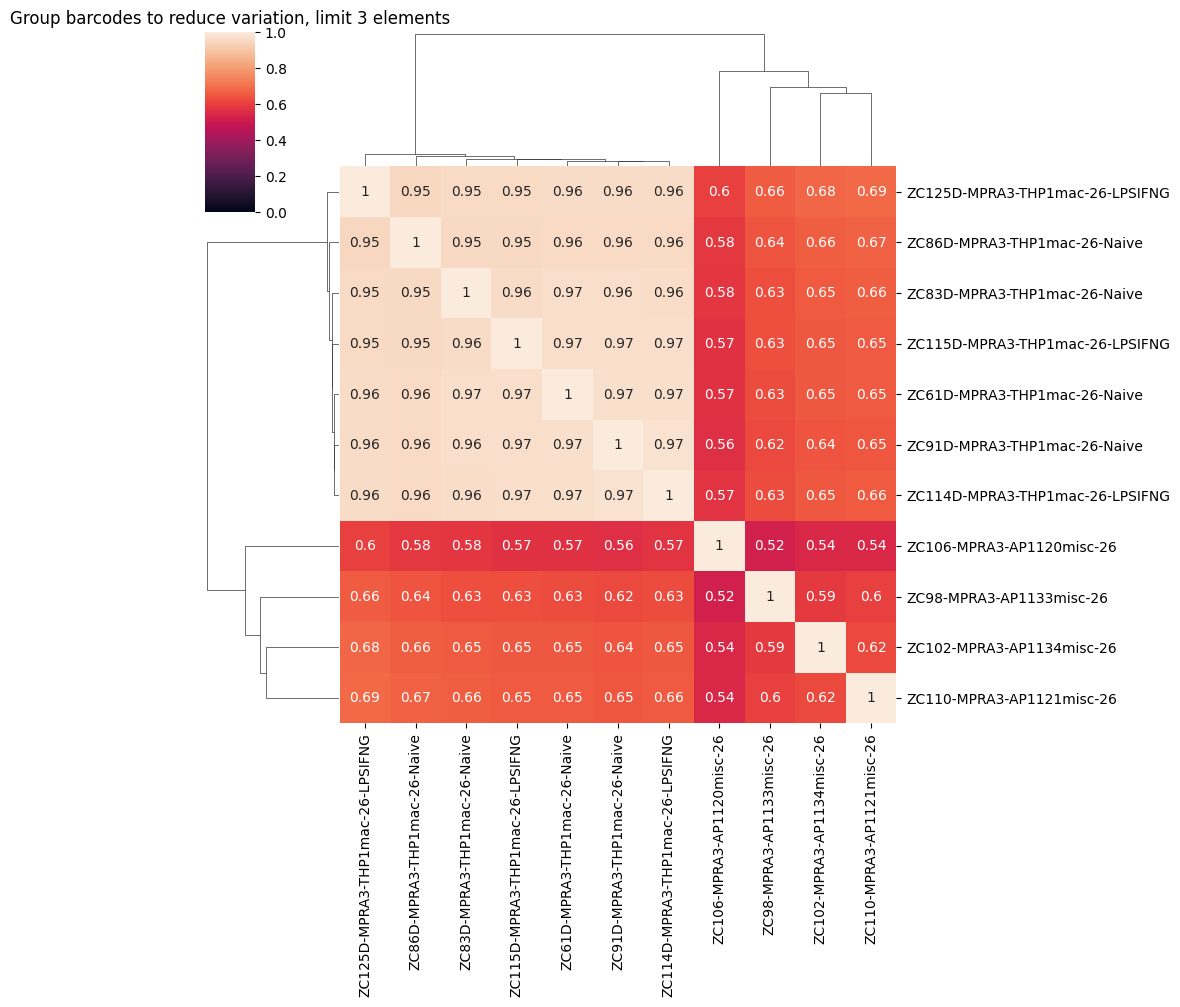

In [33]:
df_THP1 = pd.read_csv("read_counts_R1R2/THP1_DNA_RNA.csv",index_col=0).iloc[986:,:]
df_THP1_DNA = df_THP1 [['ZC83D-MPRA3-THP1mac-26-Naive',
        'ZC86D-MPRA3-THP1mac-26-Naive',
       'ZC91D-MPRA3-THP1mac-26-Naive', 
        'ZC61D-MPRA3-THP1mac-26-Naive',
       'ZC125D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC114D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC115D-MPRA3-THP1mac-26-LPSIFNG']]

DNA_columns = ['ZC102D1-MPRA3-AP1134misc-26', 'ZC102D2-MPRA3-AP1134misc-26',
               'ZC98D1-MPRA3-AP1133misc-26', 'ZC98D2-MPRA3-AP1133misc-26',
       'ZC106D1-MPRA3-AP1120misc-26', 'ZC106D2-MPRA3-AP1120misc-26',
       'ZC110D1-MPRA3-AP1121misc-26', 'ZC110D2-MPRA3-AP1121misc-26',
       ]

grouped_df= pd.read_csv("read_counts_R1R2/Brain_DNA.csv",index_col=0).iloc[986:,:][DNA_columns].groupby(process_column_name, axis=1).sum()

# Apply the function
group_assignments = apply_greedy_to_df(grouped_df,distribute_values_3element_greedy)
grouped_df['Group'] = group_assignments
grouped_df = pd.concat([grouped_df,df_THP1_DNA],axis=1)
# Example usage
index_ranges_to_drop = []
group_counts = count_group_assignments(grouped_df)
for start_idx, counts in group_counts.items():
    if len(counts)<5:
        print(f"Rows {start_idx} to {start_idx+14}: {counts}")
        index_ranges_to_drop.append([start_idx, start_idx+14])
# Create a boolean array where all elements are initially set to True
keep_mask = np.ones(len(grouped_df), dtype=bool)
# Mark rows within the specified ranges as False (to drop)
for start, end in index_ranges_to_drop:
    keep_mask[start:end+1] = False
# Use the mask to filter the DataFrame
grouped_df_filtered = grouped_df[keep_mask]

# Sum up barcode groups and assign pseudo-barcodes
pseudo_barcodes_df = sum_barcode_groups(grouped_df_filtered )
pseudo_barcodes_df['Group'] = pseudo_barcodes_df['Group']/3
pseudo_barcodes_df

import seaborn as sns
import matplotlib.pyplot as plt
sns.clustermap(pseudo_barcodes_df.drop("Group",axis=1).corr('spearman'),vmin=0,annot=True)
plt.title("Group barcodes to reduce variation, limit 3 elements")

# Use sorting method to make pseudo-barcodes for brain RNA.

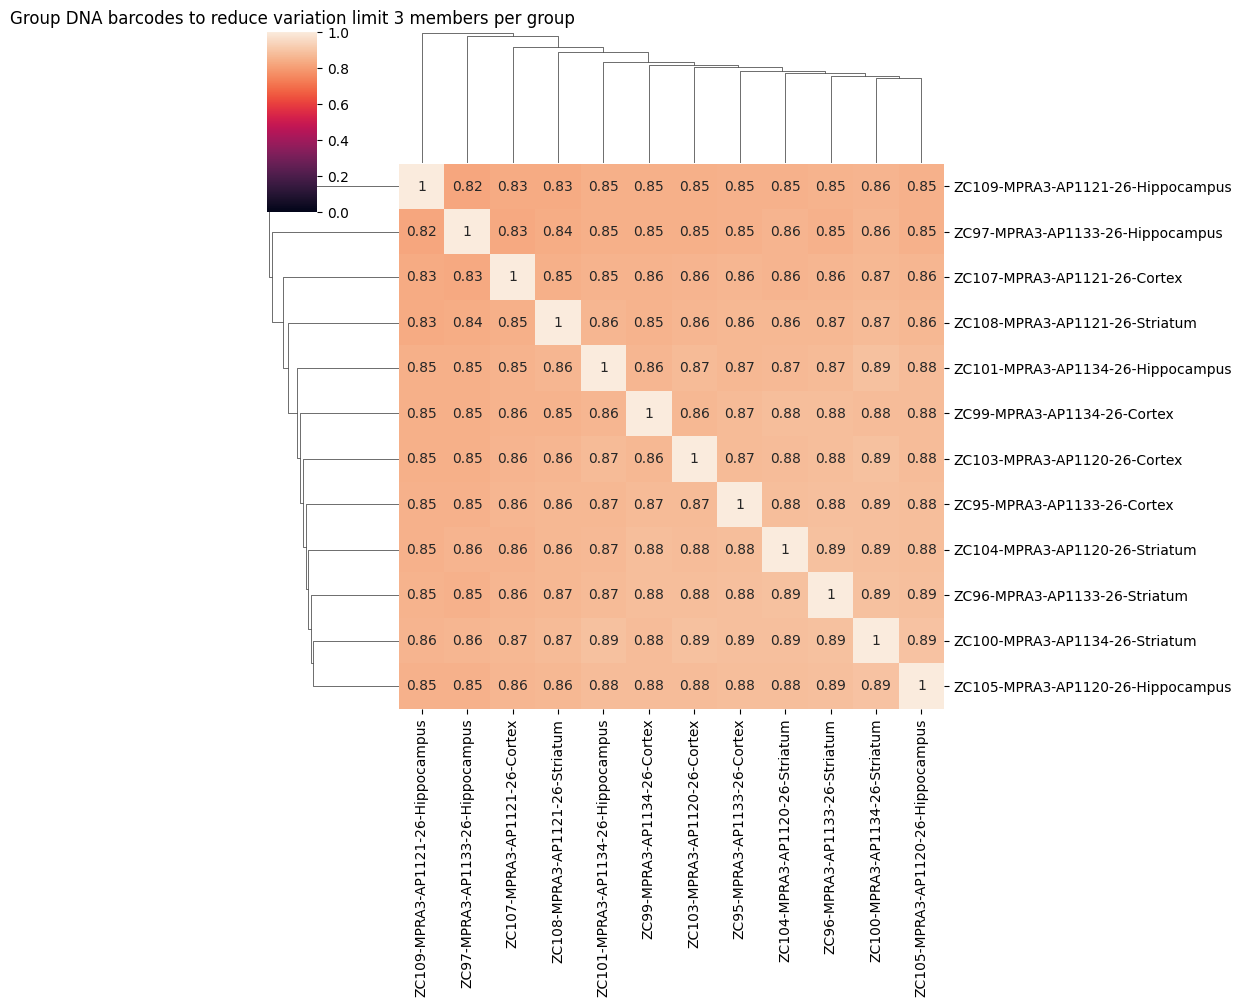

In [7]:
import numpy as np
import pandas as pd
df_brain = pd.read_csv("read_counts_R1R2/Brain_RNA.csv",index_col=0)
RNA_columns=[
'ZC99R-MPRA3-AP1134-26-Cortex',
'ZC99R2-MPRA3-AP1134-26-Cortex',
'ZC100R-MPRA3-AP1134-26-Striatum',
'ZC100R2-MPRA3-AP1134-26-Striatum',
'ZC101R-MPRA3-AP1134-26-Hippocampus',
'ZC101R2-MPRA3-AP1134-26-Hippocampus',

'ZC95R-MPRA3-AP1133-26-Cortex',
'ZC95R2-MPRA3-AP1133-26-Cortex',
'ZC96R-MPRA3-AP1133-26-Striatum',
'ZC96R2-MPRA3-AP1133-26-Striatum',
'ZC97R-MPRA3-AP1133-26-Hippocampus',
'ZC97R2-MPRA3-AP1133-26-Hippocampus',

'ZC103R-MPRA3-AP1120-26-Cortex',
'ZC103R2-MPRA3-AP1120-26-Cortex',
'ZC104R-MPRA3-AP1120-26-Striatum',
'ZC104R2-MPRA3-AP1120-26-Striatum',
'ZC105R-MPRA3-AP1120-26-Hippocampus',
'ZC105R2-MPRA3-AP1120-26-Hippocampus',

'ZC107R-MPRA3-AP1121-26-Cortex',
'ZC107R2-MPRA3-AP1121-26-Cortex',
'ZC108R-MPRA3-AP1121-26-Striatum',
'ZC108R2-MPRA3-AP1121-26-Striatum',
'ZC109R-MPRA3-AP1121-26-Hippocampus',
'ZC109R2-MPRA3-AP1121-26-Hippocampus',
]

def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('R-', '-').replace('R2-', '-')

grouped_df= df_brain.iloc[986:,:][RNA_columns].groupby(process_column_name, axis=1).sum()
grouped_df = pd.merge(grouped_df,df_index,left_index=True, right_index=True)
grouped_df=distribute_values_order(grouped_df)


pseudo_barcodes_df = sum_barcode_groups(grouped_df ).set_index("Pseudo-barcode").sort_index()
enhancer_id = grouped_df[["enhancer_id","Pseudo-barcode"]].drop_duplicates("Pseudo-barcode").set_index("Pseudo-barcode")
pseudo_barcodes_df = pd.merge(pseudo_barcodes_df,enhancer_id,left_index=True, right_index=True)

import matplotlib.pyplot as plt
sns.clustermap(pseudo_barcodes_df.drop("enhancer_id",axis=1).corr('spearman'),vmin=0,annot=True)
plt.title("Group DNA barcodes to reduce variation limit 3 members per group")


pseudo_barcodes_df[[ 'ZC100-MPRA3-AP1134-26-Striatum',
       'ZC101-MPRA3-AP1134-26-Hippocampus', 'ZC103-MPRA3-AP1120-26-Cortex',
       'ZC104-MPRA3-AP1120-26-Striatum', 'ZC105-MPRA3-AP1120-26-Hippocampus',
       'ZC107-MPRA3-AP1121-26-Cortex', 'ZC108-MPRA3-AP1121-26-Striatum',
       'ZC109-MPRA3-AP1121-26-Hippocampus', 'ZC95-MPRA3-AP1133-26-Cortex',
       'ZC96-MPRA3-AP1133-26-Striatum', 'ZC97-MPRA3-AP1133-26-Hippocampus',
       'ZC99-MPRA3-AP1134-26-Cortex','enhancer_id']].to_csv("read_counts_R1R2/BrainR1R2merged20240404_RNA_matched_barcodes.csv")

import pandas as pd

df_BrainfromTHP1 = pd.read_csv("read_counts_R1R2/BrainR1R2merged20240326_DNA_matched_barcodes.csv",index_col=0).iloc[986:,:].drop('enhancer_id',axis=1)

df_BrainfromTHP1  = pd.merge(df_BrainfromTHP1,pd.DataFrame(grouped_df[['Group','enhancer_id']]),left_index=True, right_index=True)

pseudo_barcodes_df_DNA =  sum_barcode_groups(df_BrainfromTHP1).set_index("Pseudo-barcode").sort_index()
pseudo_barcodes_df_DNA = pd.merge(pseudo_barcodes_df_DNA ,enhancer_id,left_index=True, right_index=True)
pseudo_barcodes_df_DNA[[ 'ZC100-MPRA3-AP1134-26-Striatum',
       'ZC101-MPRA3-AP1134-26-Hippocampus', 'ZC103-MPRA3-AP1120-26-Cortex',
       'ZC104-MPRA3-AP1120-26-Striatum', 'ZC105-MPRA3-AP1120-26-Hippocampus',
       'ZC107-MPRA3-AP1121-26-Cortex', 'ZC108-MPRA3-AP1121-26-Striatum',
       'ZC109-MPRA3-AP1121-26-Hippocampus', 'ZC95-MPRA3-AP1133-26-Cortex',
       'ZC96-MPRA3-AP1133-26-Striatum', 'ZC97-MPRA3-AP1133-26-Hippocampus',
       'ZC99-MPRA3-AP1134-26-Cortex','enhancer_id']].to_csv("read_counts_R1R2/BrainR1R2merged20240404_DNA_matched_barcodes.csv")

In [2]:
import pandas as pd
df_brain = pd.read_csv("read_counts_R1R2/Brain_RNA.csv",index_col=0)
RNA_columns=[
'ZC99R-MPRA3-AP1134-26-Cortex',
'ZC99R2-MPRA3-AP1134-26-Cortex',
'ZC100R-MPRA3-AP1134-26-Striatum',
'ZC100R2-MPRA3-AP1134-26-Striatum',
'ZC101R-MPRA3-AP1134-26-Hippocampus',
'ZC101R2-MPRA3-AP1134-26-Hippocampus',

'ZC95R-MPRA3-AP1133-26-Cortex',
'ZC95R2-MPRA3-AP1133-26-Cortex',
'ZC96R-MPRA3-AP1133-26-Striatum',
'ZC96R2-MPRA3-AP1133-26-Striatum',
'ZC97R-MPRA3-AP1133-26-Hippocampus',
'ZC97R2-MPRA3-AP1133-26-Hippocampus',

'ZC103R-MPRA3-AP1120-26-Cortex',
'ZC103R2-MPRA3-AP1120-26-Cortex',
'ZC104R-MPRA3-AP1120-26-Striatum',
'ZC104R2-MPRA3-AP1120-26-Striatum',
'ZC105R-MPRA3-AP1120-26-Hippocampus',
'ZC105R2-MPRA3-AP1120-26-Hippocampus',

'ZC107R-MPRA3-AP1121-26-Cortex',
'ZC107R2-MPRA3-AP1121-26-Cortex',
'ZC108R-MPRA3-AP1121-26-Striatum',
'ZC108R2-MPRA3-AP1121-26-Striatum',
'ZC109R-MPRA3-AP1121-26-Hippocampus',
'ZC109R2-MPRA3-AP1121-26-Hippocampus',
]

def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('R-', '-').replace('R2-', '-')

grouped_df= df_brain.iloc[986:,:][RNA_columns].groupby(process_column_name, axis=1).sum()

# Apply the function
group_assignments = apply_greedy_to_df(grouped_df,distribute_values_3element_greedy)
grouped_df['Group'] = group_assignments
#grouped_df = pd.concat([grouped_df,df_THP1_DNA],axis=1)
# Example usage
index_ranges_to_drop = []
group_counts = count_group_assignments(grouped_df)
for start_idx, counts in group_counts.items():
    if len(counts)<5:
        print(f"Rows {start_idx} to {start_idx+14}: {counts}")
        index_ranges_to_drop.append([start_idx, start_idx+14])
# Create a boolean array where all elements are initially set to True
keep_mask = np.ones(len(grouped_df), dtype=bool)
# Mark rows within the specified ranges as False (to drop)
for start, end in index_ranges_to_drop:
    keep_mask[start:end+1] = False
# Use the mask to filter the DataFrame
grouped_df_filtered = grouped_df[keep_mask]

# Sum up barcode groups and assign pseudo-barcodes
pseudo_barcodes_df = sum_barcode_groups(grouped_df_filtered )
pseudo_barcodes_df['Group'] = pseudo_barcodes_df['Group']/3
pseudo_barcodes_df

import seaborn as sns
import matplotlib.pyplot as plt
sns.clustermap(pseudo_barcodes_df.drop("Group",axis=1).corr('spearman'),vmin=0,annot=True)
plt.title("Group barcodes to reduce variation limit 3 members per group")
df_THP1 = pd.read_csv("read_counts_R1R2/THP1_DNA_RNA.csv",index_col=0).iloc[986:,:]
df_THP1_DNA = df_THP1 [['ZC83D-MPRA3-THP1mac-26-Naive',
        'ZC86D-MPRA3-THP1mac-26-Naive',
       'ZC91D-MPRA3-THP1mac-26-Naive', 
        'ZC61D-MPRA3-THP1mac-26-Naive',
       'ZC125D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC114D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC115D-MPRA3-THP1mac-26-LPSIFNG']]
df_THP1_DNA['Group'] = grouped_df['Group']

# Sum up barcode groups and assign pseudo-barcodes
pseudo_barcodes_df_THP1_DNA = sum_barcode_groups(df_THP1_DNA)
pseudo_barcodes_df_THP1_DNA['Group'] = pseudo_barcodes_df_THP1_DNA['Group']/3

DNA_columns = ['ZC102D1-MPRA3-AP1134misc-26', 'ZC102D2-MPRA3-AP1134misc-26',
               'ZC98D1-MPRA3-AP1133misc-26', 'ZC98D2-MPRA3-AP1133misc-26',
       'ZC106D1-MPRA3-AP1120misc-26', 'ZC106D2-MPRA3-AP1120misc-26',
       'ZC110D1-MPRA3-AP1121misc-26', 'ZC110D2-MPRA3-AP1121misc-26',
       ]
def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('D1-', 'DNA-').replace('D2-', 'DNA-')
df_Brain_DNA= pd.read_csv("read_counts_R1R2/Brain_DNA.csv",index_col=0).iloc[986:,:][DNA_columns].groupby(process_column_name, axis=1).sum()
df_Brain_DNA['Group'] = grouped_df['Group']
# Sum up barcode groups and assign pseudo-barcodes
pseudo_barcodes_df_Brain_DNA = sum_barcode_groups(df_Brain_DNA)
pseudo_barcodes_df_Brain_DNA['Group'] = pseudo_barcodes_df_Brain_DNA['Group']/3

df_THP1_RNA = pd.read_csv("read_counts_R1R2/THP1_RNA_matched_barcodes.csv",index_col=0).iloc[986:,:]
df_THP1_RNA = df_THP1_RNA[['Naive_THP1mac_ZC55_R', 'Naive_THP1mac_ZC56_R', 'Naive_THP1mac_ZC57_R',
       'Naive_THP1mac_ZC61_R', 'Naive_THP1mac_ZC82_R', 'Naive_THP1mac_ZC83_R',
       'Naive_THP1mac_ZC86_R', 'Naive_THP1mac_ZC91_R']]
df_THP1_RNA['Group'] = grouped_df['Group']
pseudo_barcodes_df_THP1_RNA = sum_barcode_groups(df_THP1_RNA)

sns.clustermap(pd.concat([pseudo_barcodes_df.drop("Group",axis=1),pseudo_barcodes_df_THP1_RNA.drop("Group",axis=1)],axis=1).corr('spearman'),vmin=0,annot=True)
#plt.title("Group barcodes to reduce variation limit 3 members per group")
#,pseudo_barcodes_df_THP1_DNA.drop("Group",axis=1),pseudo_barcodes_df_Brain_DNA.drop("Group",axis=1)

NameError: name 'apply_greedy_to_df' is not defined